In [33]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

Some notes about the state of the analysis:

1. There seems to be a decrease in V0 / [E] as a function of [E] after ~1-2 uM... why?? Check 
    1. baseline correction, 
    2. potential apparent reduction of velocity due to being too slow with the pipette,
2. The wt_dmso trail is a bit of a mess. Why? Investigate. It seems, though, that the V's are ~2x higher

* work on more robust automatic linear fitting

In [73]:
#mutant = 'wt'
#mutant = 'N214A'
#mutant = 'Q256A'
mutant = 'S284A'
#mutant = 'wt_dmso'

if mutant == 'wt':
    ks = KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt')
elif mutant == 'N214A':
    ks = KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A')
elif mutant == 'Q256A':
    ks = KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A')
elif mutant == 'S284A':
    ks = KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A')
elif mutant == 'wt_dmso':
    ks = KineticsSeries('./wt_dmso/wt_dmso.yaml', corrections='./config.yaml', prefix='./wt_dmso')
else:
    raise NameError()

Loading: 210422_20_10_5_and_2µM_MproS284A.csv...
 ... excluded
Loading: 210430_buffer_160_80_and_40µM_MproS284A.csv...
 ... excluding E=160.00 / S=5.00
Loading: 210430_20_10_5_and_2µM_MproS284A.csv...
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded


In [80]:
ps = [2.0, 5.0, 10.0, 20.0, 40.0, 80.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

ks.fit_v0(r2_threshold=0.0)

6 7


In [81]:
# fit to dimer activity model

s0s, p0s, v0s, v0errs = ks.get_set_v0s(ps, ss)

# parameters: k_cat, K_m, K_d
popt, perr = fit_mm_dimer(v0s, s0s, p0s / 20.0, v0errs=None)
print(popt)
print(perr)

[1.03959150e-02 7.40141822e+01 2.30881046e-01]
[9.47465490e-01 8.60395663e+03 1.94482190e+02]


<IPython.core.display.Javascript object>


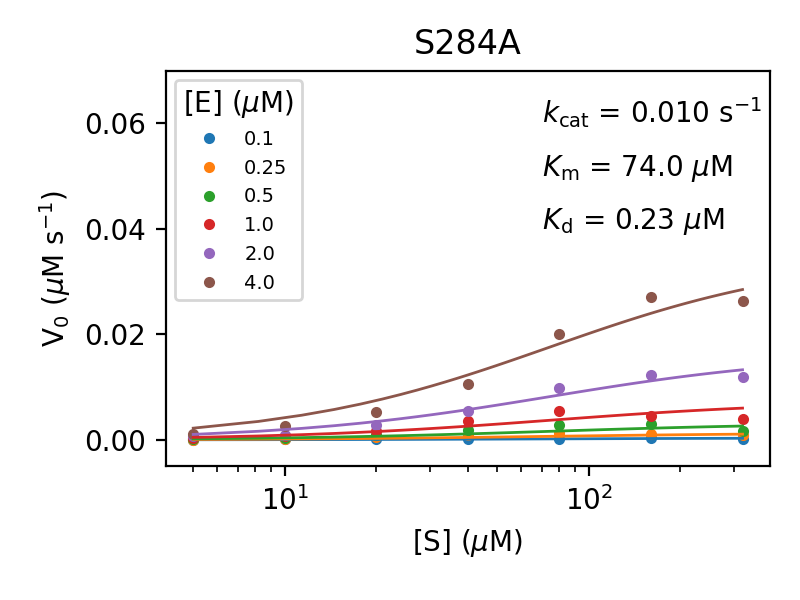

<ipython-input-82-1e678c75b390>:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.subplot(111)


In [82]:
S = np.linspace(ss.min(), ss.max(), 100)

plt.figure(figsize=(4,3))
plt.title(mutant)

ax = plt.subplot(111)

for i,p in enumerate(ps):
    s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
    ax.plot(s0s, v0s, '.')
    
plt.gca().set_prop_cycle(None)
for i,p in enumerate(ps):
    V_fit = mm_dimer( p / 20.0, S, *popt)
    ax.plot(S, V_fit, lw=1)

ax.text(70, 0.06, '$k_{\mathrm{cat}}$ = %.3f s$^{-1}$' % popt[0])
ax.text(70, 0.05, '$K_{\mathrm{m}}$ = %.1f $\mu$M' % popt[1])
ax.text(70, 0.04, '$K_{\mathrm{d}}$ = %.2f $\mu$M' % popt[2])
    
ax.set_xscale('log')
ax.set_xlabel('[S] ($\mu$M)')

ax.set_ylim([-0.005, 0.07])
ax.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')

ax.legend( np.array(ps) / 20.0, title='[E] ($\mu$M)', fontsize=7, loc=2)

plt.tight_layout()
plt.savefig('figures/%s_mm_dimer.pdf' % mutant)
plt.show()